<a href="https://colab.research.google.com/github/Diego-Cano-bit/SIGNALS-CHILE/blob/main/MAIN_REDES_CHILE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

x_train shape: (3105, 256, 256, 3)
y_train shape: (3105,)
x_val shape: (887, 256, 256, 3)
y_val shape: (887,)
x_test shape: (446, 256, 256, 3)
y_test shape: (446,)
Class Weights:  {0: 1.119322278298486, 1: 0.9036670547147846}
Epoch 1/100
98/98 [==============================] - 26s 155ms/step - loss: 0.0968 - accuracy: 0.9655 - precision_2: 0.9730 - recall_2: 0.9645 - val_loss: 1.3030 - val_accuracy: 0.7396 - val_precision_2: 0.6847 - val_recall_2: 0.9817
Epoch 2/100
98/98 [==============================] - 14s 147ms/step - loss: 0.0310 - accuracy: 0.9897 - precision_2: 0.9901 - recall_2: 0.9913 - val_loss: 0.0203 - val_accuracy: 0.9966 - val_precision_2: 0.9959 - val_recall_2: 0.9980
Epoch 3/100
98/98 [==============================] - 14s 146ms/step - loss: 0.0221 - accuracy: 0.9939 - precision_2: 0.9959 - recall_2: 0.9930 - val_loss: 0.1861 - val_accuracy: 0.9402 - val_precision_2: 1.0000 - val_recall_2: 0.8921
Epoch 4/100
98/98 [==============================] - 14s 144ms/step - lo

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


dict_keys(['loss', 'accuracy', 'precision_2', 'recall_2', 'val_loss', 'val_accuracy', 'val_precision_2', 'val_recall_2'])
{'loss': [0.09682346880435944, 0.031029608100652695, 0.022080084308981895, 0.06652067601680756, 0.031478241086006165, 0.02421685867011547, 0.01472797617316246, 0.008937657810747623, 0.02181357704102993, 0.013438074849545956, 0.018183376640081406, 0.012428013607859612, 0.009325163438916206, 0.03160608932375908, 0.014597879722714424, 0.008982961997389793, 0.011398623697459698, 0.020392194390296936, 0.009071540087461472, 0.010227967984974384, 0.022467872127890587, 0.011079774238169193, 0.00986544881016016, 0.004215833730995655, 0.003615838475525379, 0.0022918458562344313, 0.0026259012520313263, 0.007738126441836357, 0.003110816003754735, 0.008825371973216534, 0.01018664613366127, 0.00556095689535141, 0.00796506553888321, 0.0021070928778499365, 0.0012797944946214557, 0.002294371137395501, 0.0013743211748078465, 0.0009610847919248044, 0.0018226124811917543, 0.00061869219

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Division_señales/results/RESNET_03/07_accuracy.png'

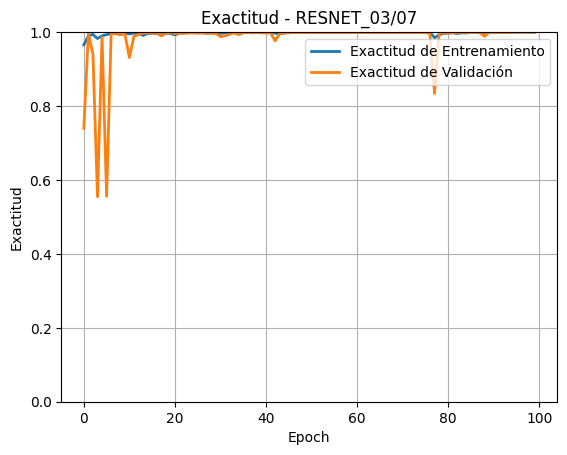

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.model_selection import KFold, train_test_split

def cargar_datos(ruta):
    datos = []
    etiquetas = []
    for clase in os.listdir(ruta):
        if clase == 'Nsr':
            etiqueta = 0
        elif clase == 'Chf':
            etiqueta = 1
        else:
            continue
        clase_ruta = os.path.join(ruta, clase)
        for archivo in os.listdir(clase_ruta):
            archivo_ruta = os.path.join(clase_ruta, archivo)
            dato = pd.read_csv(archivo_ruta, header=None).values
            matrix = np.array(dato)
            matrix_normalized = (matrix - np.min(matrix)) / (np.max(matrix) - np.min(matrix))
            cmap = plt.get_cmap('viridis')
            rgba_image = cmap(matrix_normalized)
            rgb_image = (rgba_image[:, :, :3] * 255).astype(np.uint8)
            rgb_matrix = np.array(rgb_image)
            datos.append(rgb_matrix)
            etiquetas.append(etiqueta)
    return np.array(datos), np.array(etiquetas)

def plot_metric(history, version, save_path, metric, metric_label, title, ylabel):
    plt.figure()
    plt.ylim(bottom=0)
    plt.plot(history.history[metric], label=f'{metric_label} de Entrenamiento', linewidth=2)
    plt.plot(history.history[f'val_{metric}'], label=f'{metric_label} de Validación', linewidth=2)
    plt.grid()
    plt.title(f'{title} - {version}')
    plt.ylabel(ylabel)
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.savefig(f'{save_path}/{version}_{metric}.png')
    plt.show()

def plot_accuracy(history, version, save_path):
    plot_metric(history, version, save_path, 'accuracy', 'Exactitud', 'Exactitud', 'Exactitud')

def plot_loss(history, version, save_path):
    plot_metric(history, version, save_path, 'loss', 'Pérdida', 'Pérdida', 'Pérdida')

def plot_precision(history, version, save_path):
    precision_key = [key for key in history.history.keys() if 'precision' in key.lower()][0]
    plot_metric(history, version, save_path, precision_key, 'Precisión', 'Precisión', 'Precisión')

def plot_recall(history, version, save_path):
    recall_key = [key for key in history.history.keys() if 'recall' in key.lower()][0]
    plot_metric(history, version, save_path, recall_key, 'Recall', 'Recall', 'Recall')

def save_training_history(history, version, save_path):
    file_path = f'{save_path}/{version}_historial_entrenamiento.csv'
    with open(file_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['epoch'] + list(history.history.keys()))
        for i in range(len(history.history['loss'])):
            row = [i + 1] + [history.history[key][i] for key in history.history.keys()]
            writer.writerow(row)

def test_model(version, results_dir, x_test, y_test):
    model_path = os.path.join(results_dir, f'model_{version}.h5')
    model = tf.keras.models.load_model(model_path)
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(x_test, y_test)
    y_pred = model.predict(x_test)
    y_pred_classes = (y_pred > 0.5).astype("int32")
    f1 = f1_score(y_test, y_pred_classes, average='weighted')
    report = classification_report(y_test, y_pred_classes, output_dict=True)
    csv_path = os.path.join(results_dir, f'{version}_evaluacion_modelo.csv')
    with open(csv_path, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['Métrica', 'Valor'])
        writer.writerow(['Loss', test_loss])
        writer.writerow(['Accuracy', test_accuracy])
        writer.writerow(['Precision', test_precision])
        writer.writerow(['Recall', test_recall])
        writer.writerow(['F1 Score', f1])
        writer.writerow([])
        writer.writerow(['Clase', 'Precision', 'Recall', 'F1-Score', 'Support'])
        for class_label, metrics in report.items():
            if isinstance(metrics, dict):
                writer.writerow([class_label, metrics['precision'], metrics['recall'], metrics['f1-score'], metrics['support']])
    print(f'Resultados de evaluación guardados en {csv_path}')
    conf_matrix = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.savefig(os.path.join(results_dir, f'{version}_confusion_matrix.png'))
    plt.show()

def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    x = Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv2D(filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride)(shortcut)
    x = Add()([x, shortcut])
    x = ReLU()(x)
    return x

def ResNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

# Directorios y versión
datos_dir = '/content/drive/MyDrive/Division_señales/Datos'
results_dir = '/content/drive/MyDrive/Division_señales/results'
version = 'RESNET_03/07'

# Cargar datos
x, y = cargar_datos(datos_dir)

# Dividir datos en conjuntos de entrenamiento, validación y prueba
x_train_val, x_test, y_train_val, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.2, random_state=42)

# Imprimir tamaños de los conjuntos de datos
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

kf = KFold(n_splits=5)
fold_no = 1

# Entrenar con validación cruzada
for train_index, val_index in kf.split(x_train_val):
    print(f'Training fold {fold_no}...')
    x_train_fold, x_val_fold = x_train_val[train_index], x_train_val[val_index]
    y_train_fold, y_val_fold = y_train_val[train_index], y_train_val[val_index]

    model = ResNet((256, 256, 3), 1)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

    class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                      classes=np.unique(y_train_fold),
                                                      y=y_train_fold)
    class_weights_dict = dict(enumerate(class_weights))

    history = model.fit(x_train_fold,
                        y_train_fold,
                        epochs=100,
                        verbose=1,
                        validation_data=(x_val_fold, y_val_fold),
                        class_weight=class_weights_dict)

    model.save(f'{results_dir}/model_{version}_fold{fold_no}.h5')
    print(f'Fold {fold_no} trained and saved.')

    plot_accuracy(history, f'{version}_fold{fold_no}', results_dir)
    plot_loss(history, f'{version}_fold{fold_no}', results_dir)
    plot_precision(history, f'{version}_fold{fold_no}', results_dir)
    plot_recall(history, f'{version}_fold{fold_no}', results_dir)
    save_training_history(history, f'{version}_fold{fold_no}', results_dir)

    fold_no += 1

# Evaluar el modelo final en el conjunto de prueba
model = ResNet((256, 256, 3), 1)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(x_train, y_train, epochs=100, verbose=1, validation_split=0.1, class_weight=class_weights_dict)
model.save(f'{results_dir}/model_{version}.h5')
test_model(version, results_dir, x_test, y_test)
